In [9]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Times New Roman'

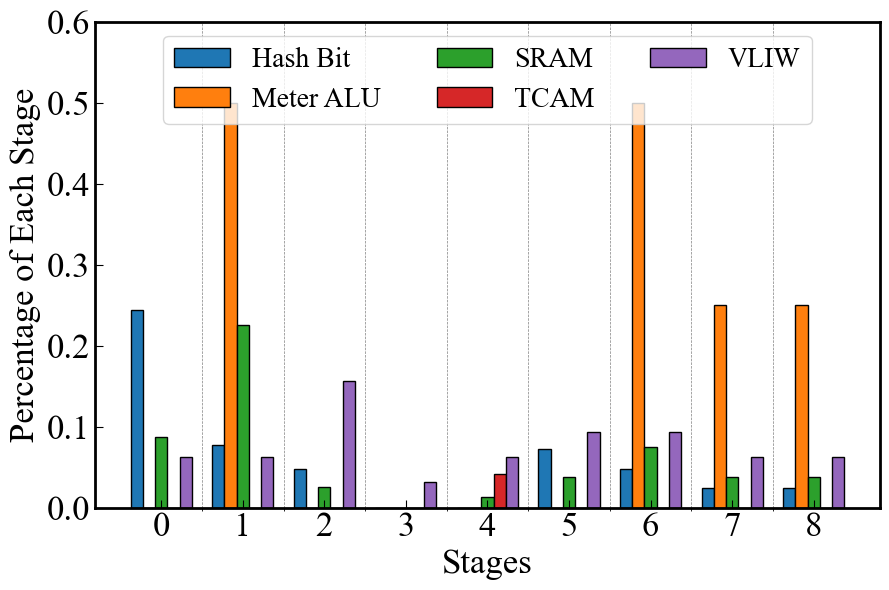

In [37]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'axes.labelsize': 25,   # 坐标轴标签字体大小
    'xtick.labelsize': 25,  # X坐标刻度字体大小
    'ytick.labelsize': 25,  # Y坐标刻度字体大小
    'legend.fontsize': 20,  # 图例字体大小
    'figure.titlesize': 20,  # 图形标题字体大小
})

# 数据
stages = np.arange(9)
hash_bit = [0.2442, 0.0769, 0.0481, 0.0, 0.0, 0.0726, 0.0481, 0.0240, 0.0240]
meter_alu = [0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.5, 0.25, 0.25]
sram = [0.0875, 0.225, 0.025, 0, 0.0125, 0.0375, 0.075, 0.0375, 0.0375]
tcam = [0, 0, 0, 0, 0.0417, 0, 0, 0, 0]
vliw = [0.0625, 0.0625, 0.15625, 0.03125, 0.0625, 0.09375, 0.09375, 0.0625, 0.0625]

# 设置柱状图宽度
width = 0.15

# 扩展数据，确保每个数据有9个元素
hash_bit_extended = hash_bit
meter_alu_extended = meter_alu
sram_extended = sram
tcam_extended = tcam
vliw_extended = vliw

# 创建图形
fig, ax = plt.subplots(figsize=(9, 6))
ax.spines['top'].set_linewidth(2)   # 设置上边框的线宽
ax.spines['right'].set_linewidth(2) # 设置右边框的线宽
ax.spines['left'].set_linewidth(2)  # 设置左边框的线宽
ax.spines['bottom'].set_linewidth(2) # 设置下边框的线宽
# 绘制每个类别的柱状图
ax.bar(stages - 2 * width, hash_bit_extended, width=width, label='Hash Bit', edgecolor='black')
ax.bar(stages - width, meter_alu_extended, width=width, label='Meter ALU', edgecolor='black')
ax.bar(stages, sram_extended, width=width, label='SRAM', edgecolor='black')
ax.bar(stages + width, tcam_extended, width=width, label='TCAM', edgecolor='black')
ax.bar(stages + 2 * width, vliw_extended, width=width, label='VLIW', edgecolor='black')

# 设置坐标轴标签和标题
ax.set_xlabel('Stages')
ax.set_ylabel('Percentage of Each Stage')
ax.set_xticks(stages)
ax.set_xticklabels([str(i) for i in range(9)])
ax.set_ylim(0, 0.6)

# 设置次刻度（在主刻度之间）
ax.set_xticks(np.arange(0.5, 8.5, 1), minor=True)

# 设置网格，只有竖向网格且网格为虚线，次刻度位置有虚线
ax.grid(True, which='minor', axis='x', linestyle='--', color='gray', linewidth=0.5)

# 只显示下坐标轴和左坐标轴的刻度
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()

# 设置刻度朝内
ax.tick_params(axis='x', direction='in', length=6)
ax.tick_params(axis='y', direction='in', length=6)

# 增加图例
ax.legend(ncol=3, loc='upper center')


# 调整布局
plt.tight_layout()

# 保存为PDF
fig.savefig("stage_percentage.pdf", format='pdf', bbox_inches='tight')

# 显示图形
plt.show()


In [2]:
import numpy as np
import pandas as pd
import hashlib
from collections import Counter
import matplotlib.pyplot as plt

In [1]:
pac = []
cnt = 0
with open("stackoverflow.txt", "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()   # 默认按空白分割，适合两个字符串
        if len(parts) >= 2:
            pac.append(parts[0])
            cnt+=1
        if cnt == 3e7:
            break

In [3]:
len(pac)

30000000

In [5]:
rows = 3
cols = 68266
countermin = [[0] * cols for _ in range(rows)]

# 3. 定义哈希函数：使用 md5 + 不同行盐确保三行独立
def hash_with_seed(s, seed):
    m = hashlib.md5()
    m.update((s + str(seed)).encode("utf-8"))
    return int(m.hexdigest(), 16)
 

In [6]:
for p in pac:
    for r in range(rows):  # 对每一行做一次哈希
        col = hash_with_seed(p, r) % cols
        countermin[r][col] += 1

In [7]:
real_freq = Counter(pac)

# === 4. 预测频次（Count-Min Query） ===
def cm_query(item):
    est = float('inf')
    for r in range(rows):
        col = hash_with_seed(item, r) % cols
        est = min(est, countermin[r][col])
    return est

# === 5. 生成三个 list ===
keys = []           # item 的 key 列表（所有不同 item）
real_list = []      # item 的真实频次
cm_list = []        # item 的 Count-Min 预测频次

for item in real_freq.keys():
    keys.append(item)
    real_list.append(real_freq[item])
    cm_list.append(cm_query(item))

# === 输出检查 ===
print("Unique items:", len(keys))
print("First 10 keys:", keys[:10])
print("Real freq (前10):", real_list[:10])
print("CM freq   (前10):", cm_list[:10])

Unique items: 1525200
First 10 keys: ['9', '1', '13', '17', '48', '19', '23', '35', '39', '43']
Real freq (前10): [62, 534, 4275, 873, 53, 13, 6, 258, 87, 112]
CM freq   (前10): [270, 623, 4375, 1009, 416, 99, 118, 369, 218, 468]


In [14]:
import random

# 随机选 10000 个 item （有重复没关系）
train_items = random.choices(keys, k=10000)

threshold = 100   # 例如 1000，可自行调整

X = []
y = []

for item in train_items:
    # 这三行是 count-min 查询得到的三个数
    x1 = countermin[0][hash_with_seed(item, 0) % cols]
    x2 = countermin[1][hash_with_seed(item, 1) % cols]
    x3 = countermin[2][hash_with_seed(item, 2) % cols]

    mn = min(x1, x2, x3)
    mx = max(x1, x2, x3)

    # 避免除以 0
    if mn == 0:
        continue

    # 新条件： (max - min) / min > threshold
    if (mx - mn)  > threshold and mn < 5000:
        X.append((x1, x2, x3))
        y.append(real_freq[item])


In [24]:
import math

powers = [2**k for k in range(0, 16)]  # 2^0 到 2^15

best_a = None
best_b = None
best_c = None
best_error = float('inf')

In [25]:
def calculate_gap(a, b):
    # 计算对数差
    log_a = math.log10(a)
    log_b = math.log10(b)

    # 计算数量级差距
    diff = abs(log_a - log_b)
    gap = math.floor(diff)  # 向下取整
    return gap

In [26]:
for a in powers:
    for b in powers:
        for c in powers:
            total_error = 0.0
            
            for (x1, x2, x3), yi in zip(X, y):
                y_hat = min(x1/a , x2/b , x3/c)
                total_error += calculate_gap(yi , y_hat)

            if total_error < best_error:
                best_error = total_error
                best_a, best_b, best_c = a, b, c

In [27]:
best_a,best_b,best_c

(32, 32, 32)

In [18]:
def cm_predict(item, a, b, c, threshold):
    # count-min 查询三个值
    x1 = countermin[0][hash_with_seed(item, 0) % cols]
    x2 = countermin[1][hash_with_seed(item, 1) % cols]
    x3 = countermin[2][hash_with_seed(item, 2) % cols]

    mn = min(x1, x2, x3)
    mx = max(x1, x2, x3)

    # 判定是否使用 y_hat 或 min
    if (mx - mn) > threshold and mn < 5000:
        # 使用训练后的 y_hat
        return min(x1/a , x2/b , x3/c)
    else:
        # 使用最小计数值
        return mn

In [19]:
cm_list_new = []
for item in real_freq.keys():
    # keys.append(item)
    # real_list.append(real_freq[item])
    # cm_list.append(cm_query(item))
    y_est = cm_predict(item, best_a, best_b, best_c, threshold)
    cm_list_new.append(y_est)



# === 输出检查 ===
print("Unique items:", len(keys))
print("First 10 keys:", keys[:10])
print("Real freq (前10):", real_list[:10])
print("CM freq   (前10):", cm_list[:10])
print("CM_new freq   (前10):", cm_list_new[:10])

Unique items: 1525200
First 10 keys: ['9', '1', '13', '17', '48', '19', '23', '35', '39', '43']
Real freq (前10): [62, 534, 4275, 873, 53, 13, 6, 258, 87, 112]
CM freq   (前10): [270, 623, 4375, 1009, 416, 99, 118, 369, 218, 468]
CM_new freq   (前10): [67.5, 623, 1093.75, 252.25, 104.0, 24.75, 29.5, 92.25, 54.5, 117.0]


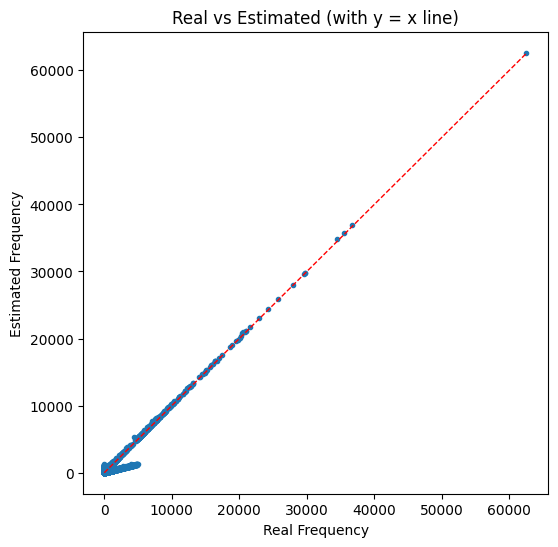

In [20]:
plt.figure(figsize=(6, 6))

# 散点
plt.scatter(real_list, cm_list_new, s=9)

# y = x 辅助线
max_v = max(max(real_list), max(cm_list_new))
plt.plot([0, max_v], [0, max_v], 'r--', linewidth=1)

plt.xlabel("Real Frequency")
plt.ylabel("Estimated Frequency")
plt.title("Real vs Estimated (with y = x line)")

# plt.grid(True)
plt.show()

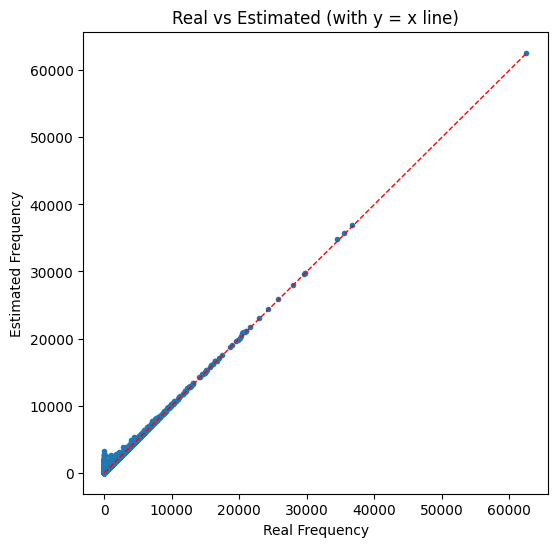

In [21]:
plt.figure(figsize=(6, 6))

# 散点
plt.scatter(real_list, cm_list, s=9)

# y = x 辅助线
max_v = max(max(real_list), max(cm_list))
plt.plot([0, max_v], [0, max_v], 'r--', linewidth=1)

plt.xlabel("Real Frequency")
plt.ylabel("Estimated Frequency")
plt.title("Real vs Estimated (with y = x line)")

# plt.grid(True)
plt.show()

In [183]:
import numpy as np

real_arr = np.array(real_list, dtype=float)
cm_new_arr = np.array(cm_list_new, dtype=float)
cm_arr = np.array(cm_list, dtype=float)

# --- Real vs CM_New ---
aae_new = np.mean(np.abs(real_arr - cm_new_arr))

# 防止除 0：过滤 real_arr == 0 的项
mask_new = real_arr != 0
are_new = np.mean(np.abs(real_arr[mask_new] - cm_new_arr[mask_new]) / real_arr[mask_new])

# --- Real vs CM (原始 Count-Min) ---
aae_cm = np.mean(np.abs(real_arr - cm_arr))

mask_cm = real_arr != 0
are_cm = np.mean(np.abs(real_arr[mask_cm] - cm_arr[mask_cm]) / real_arr[mask_cm])

print("=== Real vs CM_New ===")
print("AAE:", aae_new)
print("ARE:", are_new)

print("\n=== Real vs CM (原始) ===")
print("AAE:", aae_cm)
print("ARE:", are_cm)

=== Real vs CM_New ===
AAE: 18498.19079652686
ARE: 6880.658023170374

=== Real vs CM (原始) ===
AAE: 19125.405548207684
ARE: 7116.508299363059
